In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path
from jax import pmap
from flax.jax_utils import replicate
from flax.training.common_utils import shard
from PIL import Image
from huggingface_hub import notebook_login
import diffusers
from src.pipeline_flax_stable_diffusion import FlaxStableDiffusionPipeline, FlaxUnconditionalStableDiffusionPipeline


In [2]:

num_devices = jax.device_count()
device_type = jax.devices()[0].device_kind
print(f"Found {num_devices} JAX devices of type {device_type}.")
assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
dtype = jnp.bfloat16
pipeline, params = FlaxUnconditionalStableDiffusionPipeline.from_pretrained(
    "../diffusers-modulation/sd-pokemon-finetune",
    # tokenizer=None,
    # text_encoder=None,
    # revision="bf16",
    dtype=dtype,
)
num_inference_steps = 50
num_samples = jax.device_count()
params = replicate(params)
pipeline.safety_checker=None

Found 8 JAX devices of type TPU v3.
vae (FlaxAutoencoderKL(
    # attributes
    in_channels = 3
    out_channels = 3
    down_block_types = ['DownEncoderBlock2D', 'DownEncoderBlock2D', 'DownEncoderBlock2D', 'DownEncoderBlock2D']
    up_block_types = ['UpDecoderBlock2D', 'UpDecoderBlock2D', 'UpDecoderBlock2D', 'UpDecoderBlock2D']
    block_out_channels = [128, 256, 512, 512]
    layers_per_block = 2
    act_fn = 'silu'
    latent_channels = 4
    norm_num_groups = 32
    sample_size = 512
    scaling_factor = 0.18215
    dtype = float32
), {'decoder': {'conv_in': {'bias': Array([ 1.00122951e-01, -1.54621094e-01,  1.18506197e-02, -7.94236362e-02,
        9.90838036e-02,  2.82841921e-02,  1.57891616e-01,  7.80536532e-02,
       -9.13628042e-02,  1.62412059e-02, -2.88665146e-02,  1.12619095e-01,
        1.48431391e-01,  2.05568060e-01, -2.62500867e-02,  6.94824830e-02,
        1.95244610e-01, -9.16925892e-02,  1.52383059e-01,  1.73780680e-01,
       -7.66364112e-02, -2.02163346e-02,  4.60

AttributeError: 'tuple' object has no attribute '__module__'

In [2]:
num_devices = jax.device_count()
device_type = jax.devices()[0].device_kind
print(f"Found {num_devices} JAX devices of type {device_type}.")
assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
dtype = jnp.bfloat16
pipeline, params = FlaxStableDiffusionPipeline.from_pretrained(
    # "duongna/stable-diffusion-v1-4-flax",
    "./sd-pokemon-sd2",
    # "./sd-pokemon-retry/",
    # tokenizer=None,
    # text_encoder=None,
    # revision="bf16",
    dtype=dtype,
)
num_inference_steps = 50
num_samples = jax.device_count()
params = replicate(params)
pipeline.safety_checker=None

Found 8 JAX devices of type TPU v3.


NameError: name 'FlaxStableDiffusionPipeline' is not defined

In [4]:
def printTree(tree, d = 0):
    if (tree == None or len(tree) == 0):
        print("\t" * d, "-")
    else:
        for key, val in tree.items():
            if (isinstance(val, dict)):
                print("\t" * d, key)
                printTree(val, d+1)
            else:
                print("\t" * d,key, val.shape)

printTree(params['unet'])

 conv_in
	 bias (8, 320)
	 kernel (8, 3, 3, 4, 320)
 conv_norm_out
	 bias (8, 320)
	 scale (8, 320)
 conv_out
	 bias (8, 4)
	 kernel (8, 3, 3, 320, 4)
 down_blocks_0
	 attentions_0
		 norm
			 bias (8, 320)
			 scale (8, 320)
		 proj_in
			 bias (8, 320)
			 kernel (8, 320, 320)
		 proj_out
			 bias (8, 320)
			 kernel (8, 320, 320)
		 transformer_blocks_0
			 attn1
				 to_k
					 kernel (8, 320, 320)
				 to_out_0
					 bias (8, 320)
					 kernel (8, 320, 320)
				 to_q
					 kernel (8, 320, 320)
				 to_v
					 kernel (8, 320, 320)
			 attn2
				 to_k
					 kernel (8, 1024, 320)
				 to_out_0
					 bias (8, 320)
					 kernel (8, 320, 320)
				 to_q
					 kernel (8, 320, 320)
				 to_v
					 kernel (8, 1024, 320)
			 ff
				 net_0
					 proj
						 bias (8, 2560)
						 kernel (8, 320, 2560)
				 net_2
					 bias (8, 320)
					 kernel (8, 1280, 320)
			 norm1
				 bias (8, 320)
				 scale (8, 320)
			 norm2
				 bias (8, 320)
				 scale (8, 320)
			 norm3
				 bias (8, 320)
				 scal

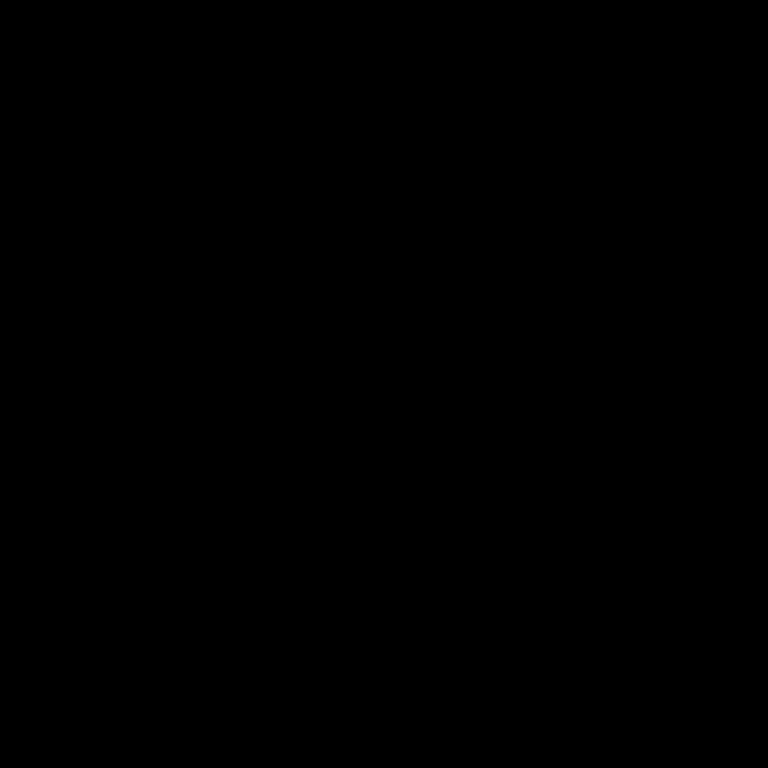

In [3]:
prng_seed = jax.random.PRNGKey(0)
prng_seed = jax.random.split(prng_seed, jax.device_count())
prompt = ""
prompt = num_samples * [prompt]
prompt_ids = pipeline.prepare_inputs(prompt)
prompt_ids = shard(prompt_ids)
images = pipeline(prompt_ids, params, prng_seed, num_inference_steps, jit=True).images
images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_samples,) + images.shape[-3:])))
images[0]


In [ ]:
# XLA is slow on TPU
# from diffusers import DiffusionPipeline
# import torch
# import torch_xla.core.xla_model as xm

# model_id = "stabilityai/stable-diffusion-xl-base-1.0"
# pipe = DiffusionPipeline.from_pretrained(model_id)

# device = xm.xla_device()
# pipe.to(device)

# prompt = "A pokemon with green eyes and red legs."
# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Compilation time is {time()-start} sec')
# image.save("pokemon.png")

# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Inference time is {time()-start} sec after compilation')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."
image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
